> **UFH DIRISA 2026 — Submission Notebook 5/6**  
> Project: *Eastern Cape Municipal Electoral Dynamics*  
> Scope: Eastern Cape Local Government Elections, 2000–2021 historical evidence with model-based 2026 scenarios.  
> Reproducibility rule: run notebooks in numerical order from the repository root.


# Phase 5 — Party Support Model

## Eastern Cape Municipal Electoral Dynamics

Phase 5 evaluates whether historical municipal party support can be used to estimate **future PR vote shares**.

### Core question

> How accurately can party vote shares in a future Eastern Cape local election be estimated from support observed in the previous local election?

### Historical backtest

- **Training transition:** 2011 → 2016
- **Holdout transition:** 2016 → 2021
- **Unit:** municipality × election transition
- **Ballot:** PR
- **Target:** change in party vote share (percentage points)

This follows the useful idea from the earlier prototype that modelled ANC swing, but extends the framework across the selected parties and evaluates every model against simple baselines.

### Selected party representation

The Phase 1 convenience table contains:

- ANC
- DA
- EFF
- UDM
- ATM

All remaining parties are represented together as **OTHER**.

`OTHER` is calculated from the complete PR vote distribution, so the six categories sum to approximately 100% in every municipality-election observation.

### Important interpretation

This is a historical model evaluation. It does **not** state who will win a future election. Phase 6 will use the validated historical evidence to construct explicitly labelled 2026 model-based scenarios.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("Run this notebook from inside the DIRISA project.")

PROJECT_ROOT = find_project_root()
PHASE1_DIR = PROJECT_ROOT / "data" / "processed" / "elections" / "phase1"
PHASE5_DIR = PROJECT_ROOT / "data" / "processed" / "models" / "phase5"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "phase5"

PHASE5_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PARTY_FILE = PHASE1_DIR / "party_shares_selected_wide_2000_2021.csv"
ELECTION_FILE = PHASE1_DIR / "municipality_election_panel_2000_2021.csv"

if not PARTY_FILE.exists():
    raise FileNotFoundError(f"Missing Phase 1 party file: {PARTY_FILE}")
if not ELECTION_FILE.exists():
    raise FileNotFoundError(f"Missing Phase 1 election file: {ELECTION_FILE}")

party = pd.read_csv(PARTY_FILE)
elections = pd.read_csv(ELECTION_FILE)

print("Project root:", PROJECT_ROOT)
print("Party table:", party.shape)
print("Election panel:", elections.shape)
display(party.head())


Project root: C:\Users\Monwabisi05\IdeaProjects\Dirisa_TeamQualification
Party table: (164, 7)
Election panel: (164, 20)


,Year,MuniCode,ANC,DA,EFF,UDM,ATM
0,2000,BUF,81.267130,13.251901,0.000000,1.509984,0.000000
1,2006,BUF,81.334215,11.932406,0.000000,1.383193,0.000000
2,2011,BUF,69.125341,20.260657,0.000000,0.735391,0.000000
3,2016,BUF,59.864250,23.451522,8.206891,1.292521,0.000000
4,2021,BUF,60.510914,19.492969,12.371231,1.103930,0.889246


## 1. Validate and complete the party-share composition

The selected-party table is a modelling convenience view. We derive `OTHER` as the residual share after the five explicitly represented parties.

This avoids incorrectly treating the selected parties as if they represented every vote cast.


In [2]:
PARTIES = ["ANC", "DA", "EFF", "UDM", "ATM"]

required = ["MuniCode", "Year"] + PARTIES
missing = [x for x in required if x not in party.columns]
assert not missing, f"Missing expected columns: {missing}"

party[PARTIES] = party[PARTIES].fillna(0.0)

party["OTHER"] = 100.0 - party[PARTIES].sum(axis=1)

# Floating-point tolerance only. Materially negative OTHER would indicate a data problem.
assert (party["OTHER"] > -1e-8).all(), "Selected party shares exceed 100%."
party["OTHER"] = party["OTHER"].clip(lower=0)

MODEL_PARTIES = PARTIES + ["OTHER"]

party["ShareSum"] = party[MODEL_PARTIES].sum(axis=1)
assert np.allclose(party["ShareSum"], 100.0, atol=1e-6)

print("Years:", sorted(party["Year"].unique()))
print("Municipality-election rows:", len(party))
print("Modelled composition:", MODEL_PARTIES)
display(party.groupby("Year")[MODEL_PARTIES].mean().round(2))


Years: [np.int64(2000), np.int64(2006), np.int64(2011), np.int64(2016), np.int64(2021)]
Municipality-election rows: 164
Modelled composition: ['ANC', 'DA', 'EFF', 'UDM', 'ATM', 'OTHER']


,ANC,DA,EFF,UDM,ATM,OTHER
Year,,,,,,
2000,75.40,10.30,0.00,11.54,0.0,2.75
2006,82.49,8.02,0.00,4.67,0.0,4.82
2011,76.98,13.63,0.00,3.02,0.0,6.37
2016,71.49,16.32,4.74,3.22,0.0,4.23
2021,67.41,13.73,7.83,2.49,2.0,6.54


## 2. Create election-to-election transitions

For each municipality, the model needs:

- current election party share;
- previous election party share;
- party swing = current share − previous share.

The main historical test uses:

- 2011 → 2016 to learn;
- 2016 → 2021 to test.

This gives 33 municipalities in each transition after Phase 1 boundary harmonisation.


In [3]:
panel = party[["MuniCode", "Year"] + MODEL_PARTIES].copy()
panel = panel.sort_values(["MuniCode", "Year"])

for p in MODEL_PARTIES:
    panel[f"prev_{p}"] = panel.groupby("MuniCode")[p].shift(1)
    panel[f"swing_{p}"] = panel[p] - panel[f"prev_{p}"]

# Attach lagged contextual variables already engineered in Phase 1.
context_cols = [
    "MuniCode", "Year",
    "PreviousTurnout_%",
    "PreviousENP",
    "PreviousMargin_pts",
    "PreviousRegisteredVoters",
]
available_context = [x for x in context_cols if x in elections.columns]
panel = panel.merge(
    elections[available_context],
    on=["MuniCode", "Year"],
    how="left",
    validate="one_to_one"
)

train = panel[panel["Year"] == 2016].copy()
test = panel[panel["Year"] == 2021].copy()

assert len(train) == 33
assert len(test) == 33
assert train[[f"prev_{p}" for p in MODEL_PARTIES]].notna().all().all()
assert test[[f"prev_{p}" for p in MODEL_PARTIES]].notna().all().all()

print("Training transition: 2011 → 2016 | rows:", len(train))
print("Holdout transition: 2016 → 2021 | rows:", len(test))


Training transition: 2011 → 2016 | rows: 33
Holdout transition: 2016 → 2021 | rows: 33


## 3. Predictor design

Each party is modelled separately as a **vote-share swing**.

Primary predictors:

- that party's previous vote share;
- previous turnout;
- previous ENP;
- previous victory margin;
- log of previous registered voters.

These are all historical values available before the target election.

We deliberately do **not** use same-election turnout, ENP, margin, or other target-election outcomes.


In [4]:
for frame in [train, test]:
    frame["LogPreviousRegisteredVoters"] = np.log1p(frame["PreviousRegisteredVoters"])

CONTEXT_FEATURES = [
    "PreviousTurnout_%",
    "PreviousENP",
    "PreviousMargin_pts",
    "LogPreviousRegisteredVoters",
]

assert train[CONTEXT_FEATURES].notna().all().all()
assert test[CONTEXT_FEATURES].notna().all().all()

def features_for(party_name):
    return [f"prev_{party_name}"] + CONTEXT_FEATURES

for p in MODEL_PARTIES:
    print(p, "->", features_for(p))


ANC

 -> ['prev_ANC', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']
DA -> ['prev_DA', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']
EFF -> ['prev_EFF', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']
UDM -> ['prev_UDM', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']
ATM -> ['prev_ATM', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']
OTHER -> ['prev_OTHER', 'PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'LogPreviousRegisteredVoters']


## 4. Baselines and candidate models

For each party, compare:

### No-change baseline
Assume the party receives the same municipal vote share as in the previous election.

### Average-swing baseline
Apply the party's average 2011→2016 swing to every municipality in 2021.

### Candidate models
- Linear Regression
- Ridge Regression
- Random Forest Regression

Because the training sample contains only 33 municipalities, simple models and baselines are especially important.


In [5]:
MODEL_BUILDERS = {
    "Linear Regression": lambda: make_pipeline(
        StandardScaler(), LinearRegression()
    ),
    "Ridge Regression": lambda: make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
    ),
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),
}

def metrics(y_true, y_pred):
    return {
        "MAE_pts": mean_absolute_error(y_true, y_pred),
        "RMSE_pts": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

evaluation_rows = []
raw_predictions = {}
fitted_models = {}

for p in MODEL_PARTIES:
    y_train_swing = train[f"swing_{p}"]
    y_test_share = test[p].to_numpy()
    previous_share = test[f"prev_{p}"].to_numpy()

    # Baseline 1: no change
    pred_no_change = previous_share.copy()
    raw_predictions[(p, "No Change Baseline")] = pred_no_change
    evaluation_rows.append({
        "Party": p,
        "Model": "No Change Baseline",
        **metrics(y_test_share, pred_no_change)
    })

    # Baseline 2: average historical swing
    avg_swing = y_train_swing.mean()
    pred_avg = previous_share + avg_swing
    raw_predictions[(p, "Average Swing Baseline")] = pred_avg
    evaluation_rows.append({
        "Party": p,
        "Model": "Average Swing Baseline",
        **metrics(y_test_share, pred_avg)
    })

    Xtr = train[features_for(p)]
    Xte = test[features_for(p)]

    for model_name, builder in MODEL_BUILDERS.items():
        model = builder()
        model.fit(Xtr, y_train_swing)
        predicted_swing = model.predict(Xte)
        predicted_share = previous_share + predicted_swing

        raw_predictions[(p, model_name)] = predicted_share
        fitted_models[(p, model_name)] = model

        evaluation_rows.append({
            "Party": p,
            "Model": model_name,
            **metrics(y_test_share, predicted_share)
        })

evaluation = pd.DataFrame(evaluation_rows)
display(
    evaluation.sort_values(["Party", "MAE_pts"]).round(3)
)


,Party,Model,MAE_pts,RMSE_pts,R2
4,ANC,Random Forest,3.117,3.963,0.905
1,ANC,Average Swing Baseline,3.239,3.931,0.906
3,ANC,Ridge Regression,4.492,6.576,0.738
0,ANC,No Change Baseline,4.496,5.490,0.817
2,ANC,Linear Regression,4.683,6.938,0.708
20,ATM,No Change Baseline,2.000,2.707,-1.203
21,ATM,Average Swing Baseline,2.000,2.707,-1.203
22,ATM,Linear Regression,2.000,2.707,-1.203
23,ATM,Ridge Regression,2.000,2.707,-1.203
24,ATM,Random Forest,2.000,2.707,-1.203


## 5. Per-party historical performance

The lowest-MAE method is identified **separately for each party**. This is a historical model-selection result, not a political ranking.

A baseline is allowed to remain the selected method if machine learning does not improve on it.


In [6]:
best_by_party = (
    evaluation.sort_values(["Party", "MAE_pts"])
    .groupby("Party", as_index=False)
    .first()
)

display(best_by_party.round(3))


,Party,Model,MAE_pts,RMSE_pts,R2
0,ANC,Random Forest,3.117,3.963,0.905
1,ATM,No Change Baseline,2.000,2.707,-1.203
2,DA,No Change Baseline,2.813,4.243,0.917
3,EFF,Average Swing Baseline,2.631,3.137,-0.034
4,OTHER,Random Forest,3.760,6.079,-0.518
5,UDM,No Change Baseline,0.997,1.649,0.801


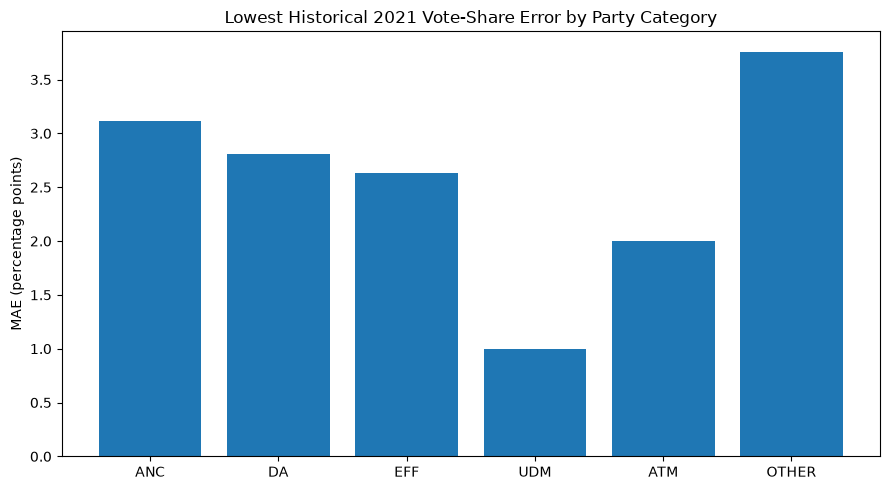

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(MODEL_PARTIES))
ax.bar(
    x,
    [best_by_party.set_index("Party").loc[p, "MAE_pts"] for p in MODEL_PARTIES]
)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_PARTIES)
ax.set_ylabel("MAE (percentage points)")
ax.set_title("Lowest Historical 2021 Vote-Share Error by Party Category")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "party_support_best_mae_2021.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Construct coherent 2021 composition predictions

Independent party models can produce:

- negative shares;
- shares that sum to more or less than 100%.

Therefore the selected per-party predictions are post-processed:

1. clip negative values to zero;
2. normalise the six categories so they sum to 100%.

This creates a coherent municipal vote-share composition for evaluation.


In [8]:
selected_model = best_by_party.set_index("Party")["Model"].to_dict()

pred_matrix = np.column_stack([
    raw_predictions[(p, selected_model[p])]
    for p in MODEL_PARTIES
])

pred_matrix = np.clip(pred_matrix, 0, None)

row_sums = pred_matrix.sum(axis=1, keepdims=True)
assert (row_sums > 0).all()
pred_matrix = 100 * pred_matrix / row_sums

actual_matrix = test[MODEL_PARTIES].to_numpy()

composition_predictions = test[["MuniCode", "Year"]].copy()

for i, p in enumerate(MODEL_PARTIES):
    composition_predictions[f"Actual_{p}"] = actual_matrix[:, i]
    composition_predictions[f"Predicted_{p}"] = pred_matrix[:, i]
    composition_predictions[f"AbsError_{p}"] = np.abs(
        actual_matrix[:, i] - pred_matrix[:, i]
    )

composition_predictions["PredictedShareSum"] = pred_matrix.sum(axis=1)
assert np.allclose(composition_predictions["PredictedShareSum"], 100.0)

display(composition_predictions.head())


,MuniCode,Year,Actual_ANC,Predicted_ANC,AbsError_ANC,Actual_DA,Predicted_DA,AbsError_DA,Actual_EFF,Predicted_EFF,AbsError_EFF,Actual_UDM,Predicted_UDM,AbsError_UDM,Actual_ATM,Predicted_ATM,AbsError_ATM,Actual_OTHER,Predicted_OTHER,AbsError_OTHER,PredictedShareSum
4,BUF,2021,60.510914,56.409047,4.101868,19.492969,24.306672,4.813703,12.371231,13.415075,1.043844,1.10393,1.339652,0.235721,0.889246,0.0,0.889246,5.631709,4.529555,1.102154,100.0
9,EC101,2021,46.628330,45.554547,1.073783,39.765638,46.989848,7.224210,4.123040,6.677068,2.554028,0.00000,0.000000,0.000000,0.146476,0.0,0.146476,9.336516,0.778538,8.557978,100.0
14,EC102,2021,56.498389,53.924506,2.573883,37.056928,38.778101,1.721173,6.176155,6.768339,0.592184,0.00000,0.000000,0.000000,0.268528,0.0,0.268528,0.000000,0.529054,0.529054,100.0
19,EC104,2021,51.818333,57.614522,5.796189,17.666981,30.026044,12.359063,5.829771,10.600239,4.770469,0.00000,0.820729,0.820729,0.827272,0.0,0.827272,23.857643,0.938466,22.919176,100.0
24,EC105,2021,52.551891,56.838301,4.286410,30.286847,31.459043,1.172196,14.799317,7.561609,7.237708,0.00000,2.741529,2.741529,0.280791,0.0,0.280791,2.081154,1.399519,0.681635,100.0


## 7. Overall vote-share error

The overall composition error treats each municipality-party share as an evaluated prediction.

This complements the per-party MAE table.


In [9]:
overall_mae = mean_absolute_error(
    actual_matrix.ravel(),
    pred_matrix.ravel()
)
overall_rmse = mean_squared_error(
    actual_matrix.ravel(),
    pred_matrix.ravel()
) ** 0.5

overall_metrics = pd.DataFrame({
    "Metric": ["Overall party-share MAE", "Overall party-share RMSE"],
    "Value_pts": [overall_mae, overall_rmse]
})

display(overall_metrics.round(3))


,Metric,Value_pts
0,Overall party-share MAE,2.502
1,Overall party-share RMSE,3.813


## 8. Historical first-place agreement as a diagnostic

For the **2021 backtest only**, we can compare which of the six modelled categories has the largest actual share with which category has the largest predicted share.

This is a diagnostic of the historical vote-share model. It is **not** a future-election forecast.


In [10]:
actual_top_idx = actual_matrix.argmax(axis=1)
pred_top_idx = pred_matrix.argmax(axis=1)

composition_predictions["ActualTopCategory"] = [
    MODEL_PARTIES[i] for i in actual_top_idx
]
composition_predictions["PredictedTopCategory"] = [
    MODEL_PARTIES[i] for i in pred_top_idx
]
composition_predictions["TopCategoryMatch"] = (
    composition_predictions["ActualTopCategory"]
    == composition_predictions["PredictedTopCategory"]
)

top_match_rate = composition_predictions["TopCategoryMatch"].mean()

historical_diagnostic = pd.DataFrame({
    "Diagnostic": [
        "2021 top-category agreement",
        "2021 top-category disagreements"
    ],
    "Value": [
        top_match_rate,
        (~composition_predictions["TopCategoryMatch"]).sum()
    ]
})

display(historical_diagnostic)


,Diagnostic,Value
0,2021 top-category agreement,0.969697
1,2021 top-category disagreements,1.000000


## 9. Model interpretation

Ridge coefficients and Random Forest feature importances are retained as diagnostics.

Because the training transition contains only 33 municipalities, these should be interpreted cautiously and **not causally**.


In [11]:
interpretation_rows = []

for p in MODEL_PARTIES:
    for model_name in ["Ridge Regression", "Random Forest"]:
        model = fitted_models[(p, model_name)]
        feats = features_for(p)

        if model_name == "Ridge Regression":
            values = model[-1].coef_
            kind = "Standardised coefficient"
        else:
            values = model.feature_importances_
            kind = "Feature importance"

        for feature, value in zip(feats, values):
            interpretation_rows.append({
                "Party": p,
                "Model": model_name,
                "Feature": feature,
                "Measure": kind,
                "Value": value
            })

feature_interpretation = pd.DataFrame(interpretation_rows)
display(feature_interpretation.head(12))


,Party,Model,Feature,Measure,Value
0,ANC,Ridge Regression,prev_ANC,Standardised coefficient,-21.429908
1,ANC,Ridge Regression,PreviousTurnout_%,Standardised coefficient,-1.372306
2,ANC,Ridge Regression,PreviousENP,Standardised coefficient,-0.481479
3,ANC,Ridge Regression,PreviousMargin_pts,Standardised coefficient,20.396505
4,ANC,Ridge Regression,LogPreviousRegisteredVoters,Standardised coefficient,-2.414203
5,ANC,Random Forest,prev_ANC,Feature importance,0.187452
6,ANC,Random Forest,PreviousTurnout_%,Feature importance,0.225355
7,ANC,Random Forest,PreviousENP,Feature importance,0.204605
8,ANC,Random Forest,PreviousMargin_pts,Feature importance,0.227783
9,ANC,Random Forest,LogPreviousRegisteredVoters,Feature importance,0.154805


## 10. Limitations

The party-support model has several important limitations:

1. **Small training sample** — the primary transition provides only 33 training municipalities.
2. **Few election cycles** — municipal elections occur infrequently, limiting temporal validation.
3. **Boundary harmonisation** — historical municipalities were mapped to the current analytical geography in Phase 1.
4. **Selected-party representation** — smaller parties are combined into `OTHER`.
5. **New-party problem** — a party with no prior-election support cannot be modelled well from its own lagged share alone.
6. **Structural change** — local political conditions, candidate changes, coalitions, turnout shocks and newly formed parties may not be captured by historical numerical features.
7. **Municipality-level inference** — the model does not reveal how demographic groups or individual voters support parties.
8. **Prediction is not certainty** — historical backtest performance defines the evidence available for later scenarios.

These limitations should accompany any later 2026 model-based output.


## 11. Save Phase 5 outputs

In [12]:
evaluation.to_csv(
    PHASE5_DIR / "party_support_model_comparison_2021.csv",
    index=False
)
best_by_party.to_csv(
    PHASE5_DIR / "party_support_selected_methods.csv",
    index=False
)
composition_predictions.to_csv(
    PHASE5_DIR / "party_support_predictions_2021.csv",
    index=False
)
overall_metrics.to_csv(
    PHASE5_DIR / "party_support_overall_metrics_2021.csv",
    index=False
)
historical_diagnostic.to_csv(
    PHASE5_DIR / "party_support_historical_diagnostic_2021.csv",
    index=False
)
feature_interpretation.to_csv(
    PHASE5_DIR / "party_support_feature_interpretation.csv",
    index=False
)

methodology = pd.DataFrame([
    ["Target", "Municipal PR party vote-share swing"],
    ["Training transition", "2011 to 2016"],
    ["Historical holdout", "2016 to 2021"],
    ["Categories", ", ".join(MODEL_PARTIES)],
    ["Primary metric", "MAE in percentage points"],
    ["Baseline 1", "No change from previous election"],
    ["Baseline 2", "Average historical swing"],
    ["Candidate models", "Linear Regression; Ridge Regression; Random Forest"],
    ["Composition constraint", "Clip at zero and normalise predicted categories to 100%"],
    ["Interpretation", "Historical model backtest; not a future-election forecast"],
], columns=["Item", "Value"])

methodology.to_csv(
    PHASE5_DIR / "phase5_methodology.csv",
    index=False
)

print("Saved Phase 5 outputs to:", PHASE5_DIR.relative_to(PROJECT_ROOT))
print("Saved figures to:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Phase 5 complete.")


Saved Phase 5 outputs to: data\processed\models\phase5
Saved figures to: reports\figures\phase5
Phase 5 complete.


## Phase 5 completion note

Phase 5 extends the earlier ANC-swing prototype into a multi-category municipal PR vote-share backtest.

The key decision for the next phase must be based on the observed 2021 historical errors:

- which method generalised best for each party category;
- whether those methods improved on no-change/average-swing baselines;
- how large the remaining vote-share errors were;
- how often the reconstructed composition identified the same leading category in the 2021 historical data.

### Next phase

**Phase 6 — 2026 Scenarios**

Phase 6 should retrain only defensible methods using the available historical record and produce explicitly labelled **model-based scenarios**, with uncertainty and limitations carried forward from Phases 4 and 5.


## Submission interpretation

Party-support modelling is evaluated as a historical PR vote-share reconstruction problem. The best method is selected separately for each party category using 2021 holdout MAE. Across the reconstructed 2021 composition, the overall party-share MAE is approximately **2.502 percentage points**. The category with the largest reconstructed share matches the observed largest-share category in **32 of 33 municipalities**.

This is a historical diagnostic of vote-share reconstruction, not a guarantee of future electoral outcomes.